In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv('train1.csv')

In [3]:
df.shape

(42000, 785)

In [4]:
df.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18878,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


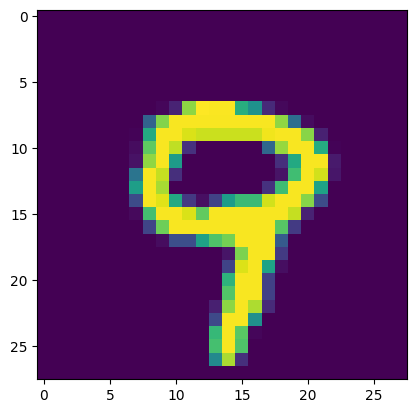

In [5]:
# here we got the MNIST data in tabular form
# now to see the image
import matplotlib.pyplot as plt
plt.imshow(df.iloc[14149,1:].values.reshape(28,28))

In [6]:
# trying without pca 
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

C:\Users\singl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
pred = knn.predict(x_test)

In [9]:
from sklearn.metrics import accuracy_score
# accuracy_score(y_test,pred)

In [10]:
from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test  = scaler.transform(x_test)

In [11]:
#Applying pca
from sklearn.decomposition import PCA
# pca = PCA(n_components=100)

In [38]:
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

In [39]:
x_train.shape

(33600, 100)

In [40]:
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

C:\Users\singl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
pred = knn.predict(x_test)

In [42]:
accuracy_score(y_test,pred)

0.9544047619047619

In [15]:
# we can automate this to see the best results 
for i in range (1,785):
    pca = PCA(n_components=i)
    scaler = StandardScaler()
    x_train_centered = scaler.fit_transform(x_train)
    x_test_centered  = scaler.transform(x_test)
    x_train_final = pca.fit_transform(x_train_centered)
    x_test_final = pca.transform(x_test_centered)
    knn = KNeighborsClassifier()
    knn.fit(x_train_final,y_train)
    pred = knn.predict(x_test_final)
    print(accuracy_score(y_test,pred))

0.2580952380952381
0.3236904761904762
0.5104761904761905
0.6663095238095238
0.7378571428571429
0.8227380952380953
0.8436904761904762
0.8721428571428571
0.886547619047619
0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425
0.9442857142857143
0.9438095238095238
0.9441666666666667
0.9442857142857143
0.9457142857142857
0.9484523809523809
0.9479761904761905
0.9478571428571428
0.9471428571428572
0.949047619047619
0.9491666666666667
0.9507142857142857
0.9513095238095238
0.95
0.9504761904761905
0.950952380952381
0.9519047619047619
0.9517857142857142
0.9527380952380953
0.9533333333333334
0.9528571428571428
0.9522619047619048
0.9522619047619048
0.9523809523809523
0.9533333333333334
0.9528571428571428
0.9530952380952381
0.9530952380952381
0.9533333333333334
0.9527380952380953
0.9533333333333334
0.9545238095238096
0.954047619047619
0.9541666666666667
0.9541666666666667
0.9546428571428571

KeyboardInterrupt: 

In [16]:
# you can see we created so many models any we can see how accuracy is increasing as we add our components 
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train) 
x_test_trf = pca.transform(x_test)

In [13]:
x_train_trf.shape

(33600, 2)

In [22]:
import seaborn as sns
# sns.scatterplot(x = x_train_trf[:,0],y=x_train_trf[:,1],hue=y_train)
# plt.show()

In [17]:
pca.explained_variance_
# eigen values 

array([3.35506576e+05, 2.44807105e+05, 2.12051035e+05, 1.85066153e+05,
       1.68000246e+05, 1.48918349e+05, 1.12510833e+05, 9.93294844e+04,
       9.51402644e+04, 7.99789771e+04, 7.18729893e+04, 7.02954186e+04,
       5.86421706e+04, 5.77978479e+04, 5.44160811e+04, 5.10942763e+04,
       4.54324809e+04, 4.40877557e+04, 4.06349678e+04, 3.95293850e+04,
       3.69465718e+04, 3.51694514e+04, 3.31919492e+04, 3.14980784e+04,
       3.03792806e+04, 2.86216441e+04, 2.79878549e+04, 2.66233147e+04,
       2.54782977e+04, 2.38073682e+04, 2.26921743e+04, 2.17431167e+04,
       2.07130988e+04, 2.02157853e+04, 1.92920932e+04, 1.85377184e+04,
       1.74405813e+04, 1.67269421e+04, 1.61818599e+04, 1.59519157e+04,
       1.55375765e+04, 1.52480605e+04, 1.43023838e+04, 1.35853438e+04,
       1.31721648e+04, 1.28124366e+04, 1.23858612e+04, 1.19793099e+04,
       1.14757321e+04, 1.09198370e+04, 1.07891523e+04, 1.05497976e+04,
       1.00392867e+04, 9.83967219e+03, 9.58435154e+03, 9.24819162e+03,
      

In [18]:
pca.components_ 
# eigen vecotrs 

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(784, 784))

<Axes: >

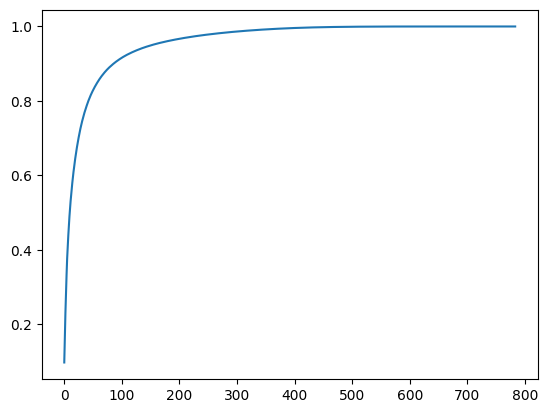

In [24]:
sns.lineplot(np.cumsum(pca.explained_variance_ratio_))
# then we can see how we can get and try to get most accuracy with least amount of the components 

In [ ]:
# Now we will start ML algorithms 